# Training Machine Learning Models for Maize Leaf Image Classification

## Retrieving Images from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishpatelresearch/maize-plant-leaf-nutrient-deficiency-dataset")

print("Path to dataset files:", path)

c:\Users\gnoceras\Documents\HackIL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 343M/343M [03:21<00:00, 1.79MB/s] 

Extracting files...


Path to dataset files: C:\Users\gnoceras\.cache\kagglehub\datasets\ashishpatelresearch\maize-plant-leaf-nutrient-deficiency-dataset\versions\1


In [5]:
import shutil
shutil.copytree(path, "../data/proximal_data", dirs_exist_ok=True)

'../data/proximal_data'

## EDA on dataset

Root: ..\data\proximal_data\Nutrition_dataset
Total images: 17627


,class,count,percent
0,train,12795,72.59
1,test,4832,27.41


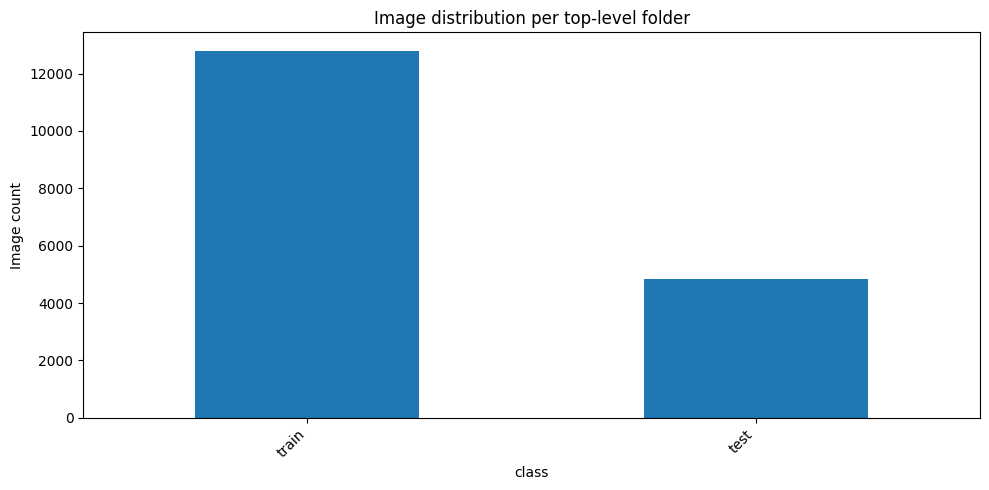

In [8]:
from pathlib import Path
from collections import Counter
import pandas as pd

import matplotlib.pyplot as plt

root = Path("../data/proximal_data/Nutrition_dataset")
if not root.exists():
    raise FileNotFoundError(f"{root} not found: {root}")

image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
counts = Counter()

for p in root.rglob('*'):
    if p.is_file() and p.suffix.lower() in image_exts:
        parts = p.relative_to(root).parts
        top_folder = parts[0] if parts else '.'
        counts[top_folder] += 1

df = pd.DataFrame(sorted(counts.items(), key=lambda x: x[1], reverse=True), columns=['class', 'count'])
df['percent'] = (df['count'] / df['count'].sum() * 100).round(2)

print(f"Root: {root}")
print(f"Total images: {df['count'].sum()}")
display(df)

ax = df.set_index('class')['count'].plot(kind='bar', figsize=(10,5))
ax.set_ylabel('Image count')
ax.set_title('Image distribution per top-level folder')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

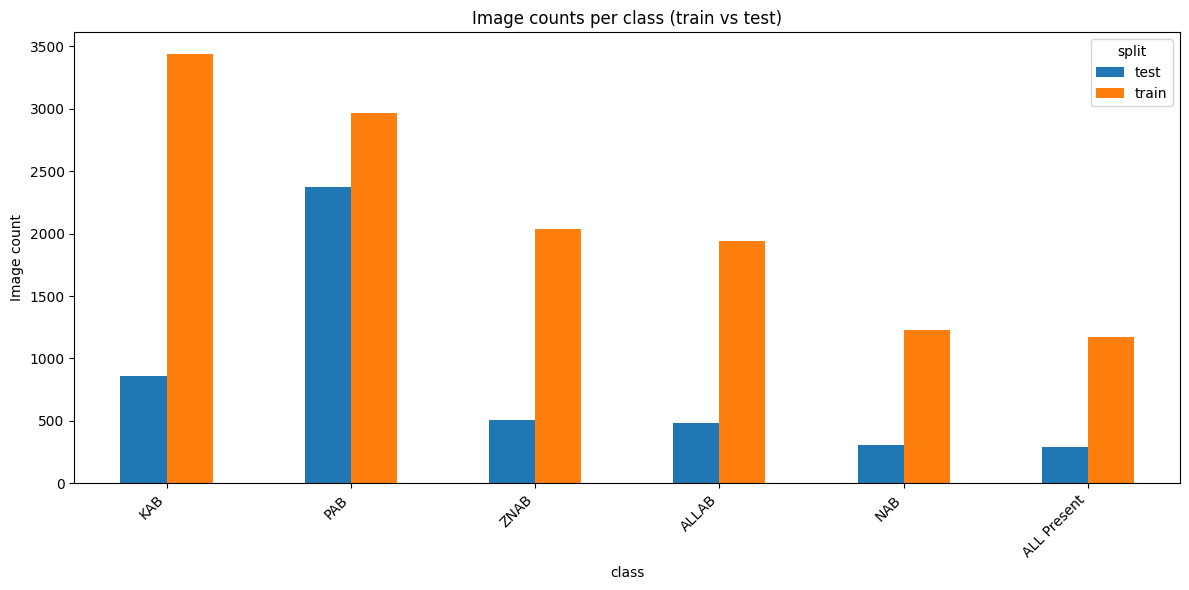

split,test,train
class,,
KAB,860,3441
PAB,2376,2970
ZNAB,509,2036
ALLAB,486,1944
NAB,307,1228
ALL Present,294,1176


In [9]:
# count images per class separately for train and test and plot
split_counts = {'train': Counter(), 'test': Counter()}

for p in root.rglob('*'):
    if p.is_file() and p.suffix.lower() in image_exts:
        parts = p.relative_to(root).parts
        if len(parts) >= 2:
            split, cls = parts[0], parts[1]
            if split in split_counts:
                split_counts[split][cls] += 1

rows = []
for split, ctr in split_counts.items():
    for cls, cnt in ctr.items():
        rows.append({'split': split, 'class': cls, 'count': cnt})

df_split = pd.DataFrame(rows)
pivot = df_split.pivot(index='class', columns='split', values='count').fillna(0).sort_values(by=list(split_counts.keys()), ascending=False)

ax2 = pivot.plot(kind='bar', figsize=(12,6))
ax2.set_ylabel('Image count')
ax2.set_title('Image counts per class (train vs test)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(pivot)

The images are not correctly distributed, I'll need to redistribute them

## Redistributing Images

In [ ]:
import random
from collections import Counter

test_frac = 0.3
classes = list(pivot.index)  # reuse existing pivot for class list

moved = []
for cls in classes:
    # gather all images for this class (from any split)
    files = [p for p in root.rglob('*') 
             if p.is_file() and p.suffix.lower() in image_exts 
             and len(p.relative_to(root).parts) >= 2 
             and p.relative_to(root).parts[1] == cls]
    if not files:
        continue
    random.shuffle(files)
    n_test = int(len(files) * test_frac)
    test_files, train_files = files[:n_test], files[n_test:]
    dest_test_dir = root / 'test' / cls
    dest_train_dir = root / 'train' / cls
    dest_test_dir.mkdir(parents=True, exist_ok=True)
    dest_train_dir.mkdir(parents=True, exist_ok=True)
    for p in test_files:
        (dest_test_dir / p.name).write_bytes(p.read_bytes()) if (dest_test_dir / p.name).exists() else p.replace(dest_test_dir / p.name)
        moved.append(('test', cls, p.name))
    for p in train_files:
        (dest_train_dir / p.name).write_bytes(p.read_bytes()) if (dest_train_dir / p.name).exists() else p.replace(dest_train_dir / p.name)
        moved.append(('train', cls, p.name))

# summarize new distribution
new_counts = {'train': Counter(), 'test': Counter()}
for split, cls, _ in moved:
    new_counts[split][cls] += 1

rows = []
for split in ['train', 'test']:
    for cls in classes:
        rows.append({'split': split, 'class': cls, 'count': new_counts[split].get(cls, 0)})

df_new = pd.DataFrame(rows)
pivot_new = df_new.pivot(index='class', columns='split', values='count').fillna(0).loc[classes]

print(f"Desired split: test={test_frac:.0%}, train={(1-test_frac):.0%}")

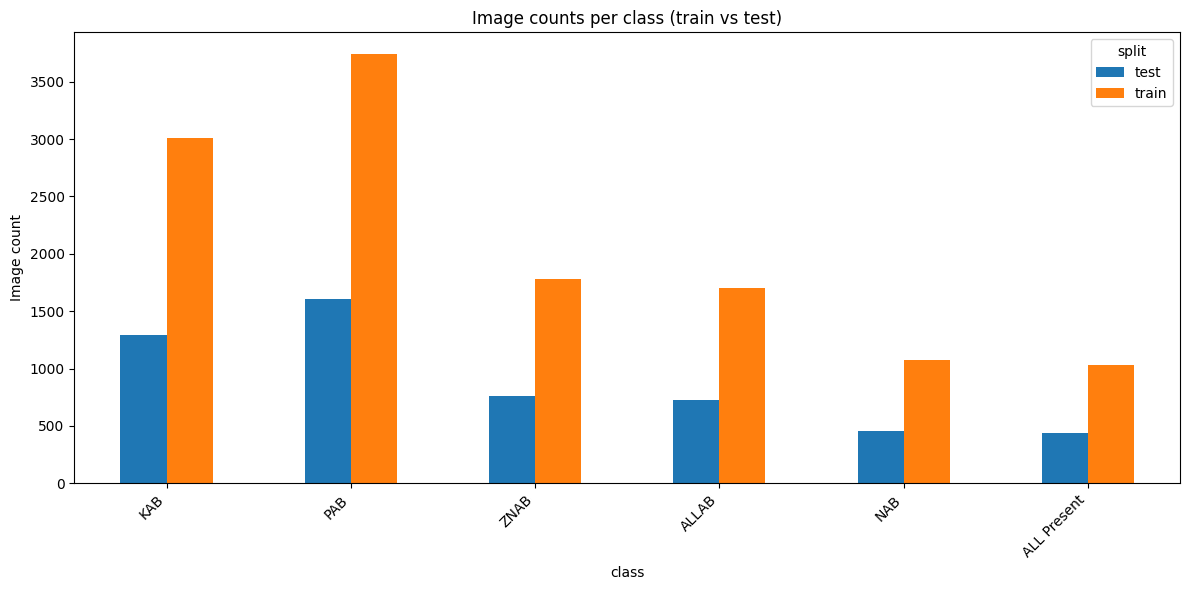

split,test,train
class,,
KAB,1290,3011
PAB,1603,3743
ZNAB,763,1782
ALLAB,729,1701
NAB,460,1075
ALL Present,441,1029


In [12]:
ax2 = pivot_new.plot(kind='bar', figsize=(12,6))
ax2.set_ylabel('Image count')
ax2.set_title('Image counts per class (train vs test)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(pivot_new)